In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
archivo_may_torre = "../data/002_intermediate/may_torre.parquet"

may_torre = pd.read_parquet(archivo_may_torre)

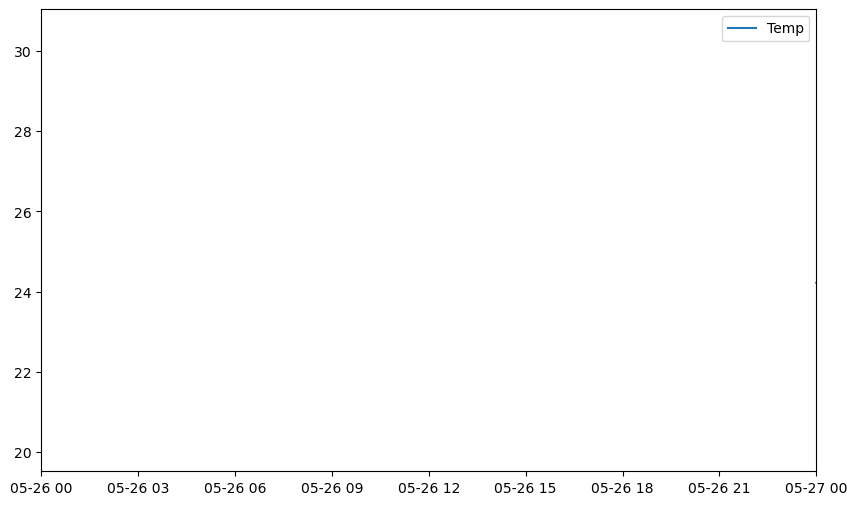

In [3]:
#GRAFICA DE PROMEDIOS CADA 10 MINUTOS
fig, ax = plt.subplots(figsize=(10, 6))

f1 = pd.to_datetime("2026-05-26")
f2 = f1 + pd.Timedelta("24h")



ax.plot(may_torre["Temp"].resample('10min').mean(), label='Temp')
ax.set_xlim(f1, f2)

ax.legend()

In [4]:

#GRAFICAS EN SUBPANELES
fig = go.Figure
fig = make_subplots(rows = 2, cols = 2,  specs=[[{}, {}], [{"colspan": 2}, None]], subplot_titles = ( "C02" ,  "Temperaturas" ,  "Humedad Relativa"  ))


fig.add_trace(
   go.Scatter(x = may_torre.index, y = may_torre["CO2"], name="CO2") 
, row=1, col = 1)

fig.add_trace(
    go.Scatter(x = may_torre.index, y = may_torre["BH"],name="Bulbo Húmedo"),row=2, col=1)
fig.add_trace(
   go.Scatter(x = may_torre.index, y = may_torre["Temp"],name="Temperatura"), row=2, col = 1)
fig.add_trace(
   go.Scatter(x = may_torre.index, y = may_torre["PC"],name="Punto de Condensación"), row=2, col = 1)

fig.add_trace(
   go.Scatter(x = may_torre.index, y = may_torre["% HR"], name="Humedad Relativa"), row=1, col=2 )
fig.show()

In [5]:
#graficar cada timestep Torre02 
columnas_t0 = [col for col in may_torre.columns if col.startswith("T0")]

may_torre["Tave"] = may_torre[columnas_t0].mean(axis=1)

may_torre.head()

,T03,T04,T05,T06,T07,T08,T01,T02,Temp,BH,PC,% HR,CO2,Tave
2026-05-27 00:00:00,24.546667,24.390000,24.336667,24.046667,23.823333,23.653333,24.763333,24.903333,24.4,18.3,15.6,58.3,408,24.307917
2026-05-27 00:01:00,24.346667,24.126667,24.100000,23.870000,23.580000,23.476667,24.676667,24.830000,24.0,18.2,15.6,59.4,403,24.125833
2026-05-27 00:02:00,24.180000,23.996667,24.010000,23.820000,23.526667,23.536667,24.630000,24.693333,24.1,18.2,15.6,59.3,414,24.049167
2026-05-27 00:03:00,24.233333,24.080000,24.026667,23.843333,23.580000,23.546667,24.616667,24.693333,24.2,18.2,15.6,59.1,410,24.077500
2026-05-27 00:04:00,24.373333,24.176667,24.123333,23.933333,23.736667,23.683333,24.730000,24.783333,24.3,18.3,15.6,58.7,424,24.192500


In [6]:
#graficar cada columna de T0 y Tave
columnas = [col for col in may_torre.columns if col.startswith("T0")] + ["Tave"]

fig = px.line(may_torre,
              x=may_torre.index, 
              y=columnas)


for trace in fig.data:
    if trace.name == "Tave":
        trace.line.width = 3 
        trace.opacity = 1.0
    else:
        trace.opacity = 0.3

fig.show()